In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
from sklearn.model_selection import train_test_split

In [2]:
best_rf = joblib.load("best_random_forest.pkl")

X = joblib.load("X_full.pkl")
y = joblib.load("y_full.pkl")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [3]:
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

In [4]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[175,  14],
       [ 42,  31]])

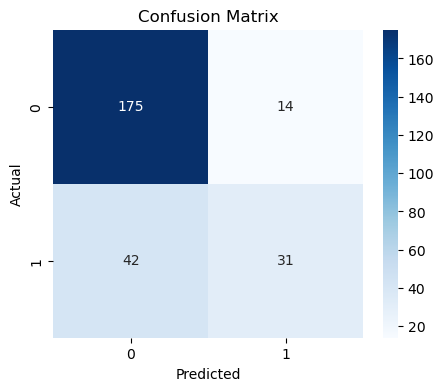

In [5]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [6]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.93      0.86       189
           1       0.69      0.42      0.53        73

    accuracy                           0.79       262
   macro avg       0.75      0.68      0.69       262
weighted avg       0.77      0.79      0.77       262



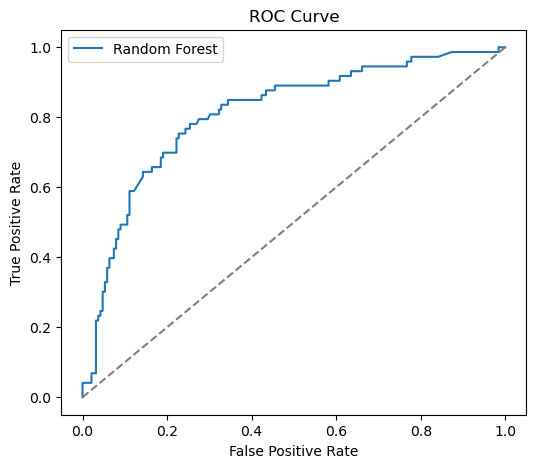

In [7]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1], [0,1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [8]:
roc_auc_score(y_test, y_proba)


0.8108284409654273